# Building a grounded memory worker: an iterative distillation experiment

**Project:** SDP 2026 memory engine · **Experiment date:** 8 October 2026

**Scope correction:** the product is general-purpose memory. The coding-focused runs below are initial experiments. The automatic coding-only second stage was stopped before training; broader training and evaluation are recorded from current receipts in Section 12c.

This notebook reconstructs the actual local, AI-assisted experiment from saved artifacts. It records unsuccessful attempts and measured limitations as well as successful runs. It is a research record, not a claim that every experiment was originally conducted inside Jupyter.

**Question:** Can a small model on an 8 GB laptop GPU extract durable facts with exact evidence, synthesize supported observations, and answer with citations?

Run All refreshes tables and figures from local receipts. It does **not** start training, download weights, modify databases, or invoke a paid teacher. Outputs remain visible when the notebook is shared without large ignored datasets. Missing results are explicitly marked pending.

In [1]:
from pathlib import Path
from collections import Counter
from datetime import datetime, timezone
import json, hashlib, re, ast, sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Cargo.toml').exists())
SLM = ROOT / 'slm-distill'
DATA = SLM / 'data/research-v2'
FIG = SLM / 'reports/figures'
FIG.mkdir(parents=True, exist_ok=True)
def read(path):
    p = Path(path)
    return json.loads(p.read_text()) if p.exists() else None
def rows(path):
    p = Path(path)
    return [json.loads(line) for line in p.read_text().splitlines() if line.strip()] if p.exists() else []
def show(value):
    display(pd.DataFrame(value)) if isinstance(value, list) else display(value)
def digest(path): return hashlib.sha256(Path(path).read_bytes()).hexdigest()
def missing(label): display(Markdown(f'**Pending / unavailable:** {label}. No result is inferred.'))
print('Report refreshed:', datetime.now(timezone.utc).isoformat())
print('Python:', sys.version.split()[0])

Report refreshed: 2026-10-08T15:13:00.327500+00:00
Python: 3.12.13


## 1. Define the task and acceptance criteria before comparing models

The unavailable original worker artifact meant we needed a reproducible replacement. The worker has three tasks:

| Task | Input | Output and acceptance |
|---|---|---|
| Extraction | Timestamped events + earlier facts | Durable claims, exact source quotes, valid source indices, entity/slot/value and correction metadata |
| Consolidation | Accepted facts | Useful observations supported by at least two distinct supplied facts |
| Reflection | Question + retrieved evidence | Answer with valid citations, or explicit insufficient evidence |

PostgreSQL is the evidence store; Neo4j is a derived projection. A queued retain response alone does not prove extraction or graph completion. Final operational checks must follow jobs through extraction, consolidation, projection, retrieval and correction.

We distinguish **schema acceptance**, **semantic support**, **reference coverage**, and **live pipeline completion**. These are different measurements.

## 2. Iteration ledger: observation → hypothesis → change → check

| Iteration | Observation | Hypothesis and intervention | Evidence / remaining boundary |
|---|---|---|---|
| Bootstrap 1.7B | Original GGUF unavailable | Learn the output contract from deterministic examples | Excellent synthetic scores; not evidence of natural conversation quality |
| Naturalistic refinement | Synthetic success did not transfer | Add teacher-labeled coding timelines and deterministic replay | Natural extraction remained weak; exact quotes and IDs frequently failed |
| Memory optimization | Full output logits caused OOM | Checkpoint answer-only output-head chunks | Training completed within laptop capacity |
| Structured decoding | Valid-looking claims had invalid source attribution/IDs | Bind source and quote together; constrain enums and existing IDs | Original blocked job completed with the 1.7B bridge worker |
| Stronger base | Remaining errors were semantic as well as structural | Use Qwen3-4B-Instruct-2507 and NF4 QLoRA | 7,141-token smoke OOM; 4,091-token smoke passed after dtype correction |
| Corpus expansion | Narrow examples could encourage memorization | Public traces + diverse stacks/domains/behaviors; family/repository splits | Audit, counts and leakage receipts below |
| Label adjudication | Auditor incorrectly rejected valid null timestamps | Re-review flags against the actual worker contract | Keep original audit and revised decisions; exclude remaining rejected cases |
| Stage 2 + comparison | Need evidence that fine-tuning helps the stronger base | Matched decoder/quantization comparison and fresh held-out subset | Results appear only when their receipts exist |

Changes to base, data and decoder occurred together across generations. Cross-generation improvement cannot be attributed to model size alone.

## 3. Bootstrap: useful contract learning, insufficient generalization

The first adapter used Qwen3-1.7B, 1,260 training examples, 140 validation examples and 280 synthetic test examples. The matched 28-case comparison below uses identical prompts with thinking disabled. CPU/GPU differed, so its latency is not a fair speed comparison.

In [2]:
comparison = read(SLM/'data/eval/bootstrap-comparison.json')
if comparison:
    show([{'model': k, 'n': comparison['n'], **comparison[k]} for k in ('base','bootstrap')])
    print(comparison['scope'])
    print('Latency comparable:', comparison['latency_comparison_valid'])
for label, path in [('bootstrap synthetic test','bootstrap-student-full'), ('refined synthetic test','refined-bootstrap-full')]:
    result = read(SLM/f'data/eval/{path}/summary.json')
    if result: print(label); display(result)
    else: missing(label)

,model,n,accepted,exact
0,base,28,27,13
1,bootstrap,28,28,28


first 28 identical synthetic held-out cases; exact slot/support/citation targets, not natural conversation accuracy
Latency comparable: False
bootstrap synthetic test


{'model': 'memex-extractor',
 'dataset_sha256': 'd44e9139e24f0fe2fe8aa70106888948574fa898854bf470e9e8d461b8cecc50',
 'scope': 'synthetic held-out project identities; no real-world accuracy claim',
 'cpu_only': False,
 'count': 280,
 'counts': {'extract:total': 160,
  'extract:accepted': 160,
  'extract:first_try': 160,
  'extract:semantic_exact': 160,
  'tp': 160,
  'fp': 0,
  'fn': 0,
  'secret_leaked': 0,
  'consolidate:total': 40,
  'consolidate:accepted': 40,
  'consolidate:first_try': 40,
  'consolidate:semantic_exact': 40,
  'reflect:total': 80,
  'reflect:accepted': 80,
  'reflect:first_try': 80,
  'reflect:semantic_exact': 80},
 'seconds': 457.133}

refined synthetic test


{'model': 'memex-extractor:local-v1',
 'dataset_sha256': 'd44e9139e24f0fe2fe8aa70106888948574fa898854bf470e9e8d461b8cecc50',
 'scope': 'synthetic held-out project identities; no real-world accuracy claim',
 'cpu_only': False,
 'count': 280,
 'counts': {'extract:total': 160,
  'extract:accepted': 160,
  'extract:first_try': 160,
  'extract:semantic_exact': 138,
  'tp': 144,
  'fp': 23,
  'fn': 16,
  'secret_leaked': 0,
  'consolidate:total': 40,
  'consolidate:accepted': 39,
  'consolidate:first_try': 38,
  'consolidate:semantic_exact': 39,
  'reflect:total': 80,
  'reflect:accepted': 80,
  'reflect:first_try': 80,
  'reflect:semantic_exact': 80},
 'seconds': 1273.547}

## 4. Natural conversations exposed the failure

The refined 1.7B adapter mixed teacher-labeled conversations with replay. Its naturalistic extraction result under the earlier unconstrained decoder was only 18 accepted windows out of 33. This set was subsequently used for diagnosis, so it is **development evidence**, not a fresh final test.

The semantic judge's supported fraction is measured over emitted claims in accepted windows. Its earlier recall calculation also excludes failed windows; it must not be presented as end-to-end recall. Later comparisons retain failures in the coverage denominator.

In [3]:
natural = read(SLM/'data/pi-corpus/eval/local-v1.json')
if natural:
    e=natural['extract']
    show([{'task':'extract','n':e['windows'],'accepted_fraction':e['accepted'],'first_try_fraction':e['first_try']},
          {'task':'consolidate','n':natural['consolidate']['items'],'accepted_fraction':natural['consolidate']['accepted']},
          {'task':'reflect','n':natural['reflect']['items'],'accepted_fraction':natural['reflect']['accepted']}])
    display(e.get('judge'))
    print('Representative validator failures:')
    for failure in e.get('failures',[])[:3]: print('-', failure)
else: missing('1.7B naturalistic evaluation')

,task,n,accepted_fraction,first_try_fraction
0,extract,33,0.545455,0.515152
1,consolidate,10,0.600000,NaN
2,reflect,32,0.968750,NaN


{'planted_visible': 30,
 'recall': 0.5,
 'claims': 43,
 'secret': 0.023255813953488372,
 'supported': 0.6744186046511628,
 'trivial': 0.023255813953488372,
 'unsupported': 0.27906976744186046}

Representative validator failures:
- every claim needs paired source indices and exact quotes: claim "The readings SQLite table has meterId as a non-nullable text reference to meters.id, recordedAt
- claim "The wattwatch readings endpoint fails when SQLite compares a timestamp string to an ISO date because...": quote "src/routes/api/meters/[id]/readings/+ser
- extraction schema: related.assertion_id must be a UUID


## 5. Fix the representation without weakening validation

The canonical API uses parallel `source_indices` and `quotes` arrays. The constrained generation format emits `source_quotes: [{source_index, quote}]` first, binding each quote to visible spans from that event. A lossless codec restores the API contract. Consolidation identifiers are restricted to supplied facts. The Python teacher/training pipeline and Rust runtime share schema files.

Exact text does **not** imply entailment: a model can quote a rejected proposal and still incorrectly describe it as a decision. Semantic grading remains necessary. Short teacher quotes are widened to the shortest permitted containing span; source index and claim statement stay unchanged.

In [4]:
schema_files = [ROOT/'src/model/extract_schema.json', ROOT/'src/model/consolidate_schema.json', ROOT/'src/model/paired_sources.txt']
show([{'file':str(p.relative_to(ROOT)), 'sha256':digest(p), 'bytes':p.stat().st_size} for p in schema_files])

,file,sha256,bytes
0,src/model/extract_schema.json,6da41f75e14a316c5335e3587db678cbe41d2ef8fe11ca...,3663
1,src/model/consolidate_schema.json,ac89fc0a3c4c993715ea9154affebf200912a13013cd4d...,1064
2,src/model/paired_sources.txt,f802c0c4790fcead4400a860aebb243bdd351fc2d4964c...,265


## 6. Research-informed base model and training method

Selected **[Qwen3-4B-Instruct-2507](https://huggingface.co/Qwen/Qwen3-4B-Instruct-2507)**, Apache-2.0, revision `cdbee75f17c01a7cc42f958dc650907174af0554`. Its non-thinking instruction behavior and compatible Qwen3 export path made it a practical controlled candidate. Official instruction-following results motivated the choice; they are not project measurements.

[Qwen3.5-4B](https://huggingface.co/Qwen/Qwen3.5-4B) was considered, but a different architecture/export path would add uncertainty. We do not claim the selected model is globally optimal.

The implementation uses Transformers + PEFT + bitsandbytes: NF4, double quantization, bfloat16 compute, rank-16 LoRA, alpha 32, dropout 0.05, answer-only loss and gradient checkpointing. See [PEFT quantization documentation](https://huggingface.co/docs/peft/developer_guides/quantization). This is **sequence-level distillation** from teacher-generated targets, not teacher-logit/KL distillation.

Hardware: RTX 4070 Laptop GPU, 8 GB nominal VRAM. A 7,141-token smoke attempt ran out of memory. Reducing to 4,091 tokens then exposed an fp32-hidden-state/bf16-output-head mismatch; an explicit cast fixed it. The two-step smoke test passed at approximately 6.2 GB peak allocation. Training excludes examples over 4,096 tokens rather than silently truncating labels.

## 7. Data provenance and generalization strategy

1. **Public traces:** [Nebius SWE-rebench OpenHands trajectories](https://huggingface.co/datasets/nebius/SWE-rebench-openhands-trajectories), CC-BY-4.0. We sampled 52 distinct repositories from the fetched source slice, constructing 144 windows. Repository-disjoint allocation: 40 train / 6 validation / 6 test repositories. These are relabeled memory tasks, not copied agent responses. Provenance retains repository, issue, trajectory, event range and source hash.
2. **Fresh synthetic conversations:** varied software stacks, project domains and memory behaviors, labeled by the authenticated Pi teacher. These are synthetic, not human annotations.
3. **Earlier examples:** naturalistic teacher corpus plus bounded deterministic replay. Repeated epochs/replay exposure are not additional unique examples.

[LongMemEval](https://github.com/xiaowu0162/LongMemEval) informed coverage of temporal reasoning, updates and abstention. It was not used as training data and no LongMemEval score is claimed.

Quantity is justified as a bounded software-memory fine-tuning experiment. It is not evidence of general intelligence or broad real-world reliability. Extraction, consolidation and reflection from one episode are correlated.

In [5]:
manifest=read(DATA/'expanded-manifest.json')
if manifest:
    show([{'split':s,'examples':v['examples'],'episodes':v['episodes'],**v['tasks']} for s,v in manifest['counts'].items()])
    total=sum(v['examples'] for v in manifest['counts'].values())
    print('Total validated rows:',total)
    print('Leakage checks:',manifest['leakage_checks'])
    print('Exact duplicate removals:',len(manifest['duplicates_removed']))
    print('Stage 2 planned exposure:',manifest['stage2'])
    print('Fresh evaluation:',manifest['fresh_evaluation'])
else: missing('frozen expanded corpus')

,split,examples,episodes,extract,consolidate,reflect
0,train,1569,729,768,341,460
1,val,396,147,171,96,129
2,test,431,153,182,98,151


Total validated rows: 2396
Leakage checks: exact prompt, project family, public repository: passed
Exact duplicate removals: 12
Stage 2 planned exposure: {'new_training_examples': 1026, 'replay_examples': 128}
Fresh evaluation: {'n': 60, 'sha256': '66e3ba2e9fab2490735c350163db4b72f8b2b569a521f90b757ad93605074f76'}


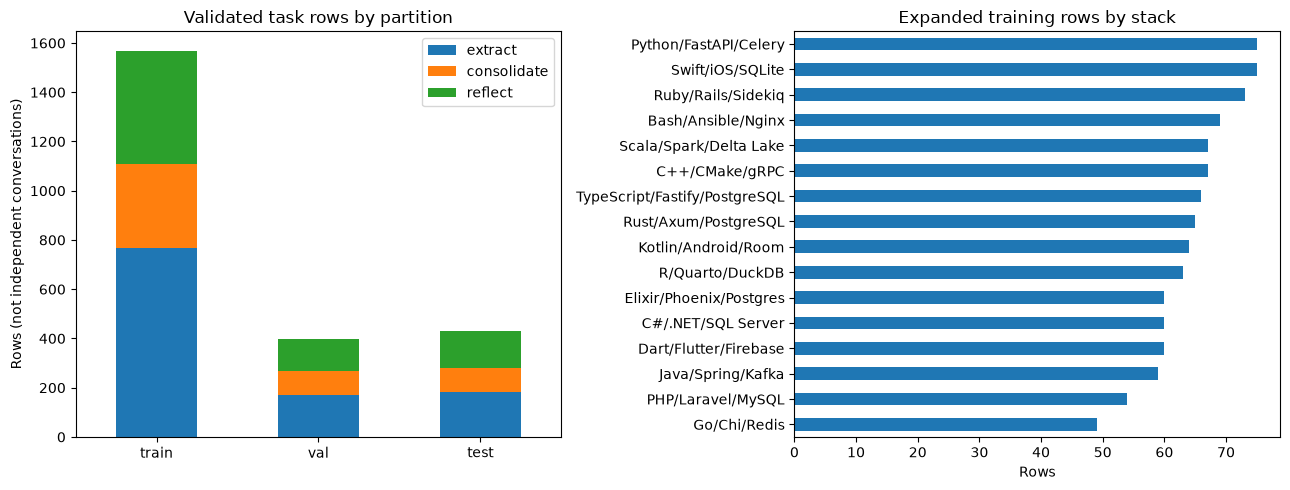

Expanded training coverage: {'stack': 16, 'domain': 12, 'behavior': 16}


,behavior,training_rows
0,insufficient evidence and abstention,72
1,multi-source evidence requiring two events,71
2,untrusted tool instructions that must be ignored,79
3,credential-shaped synthetic secret to omit,58
4,ownership and changing responsibilities,72
5,explicit correction and superseded value,69
6,long noisy tool output containing durable result,63
7,successful tool-confirmed workaround,67
8,failed command versus proposed solution,73
9,user preferences with exceptions,73


In [6]:
if manifest:
    fig, axes=plt.subplots(1,2,figsize=(13,5))
    counts=pd.DataFrame({s:v['tasks'] for s,v in manifest['counts'].items()}).T
    counts.plot.bar(stacked=True,ax=axes[0],rot=0,title='Validated task rows by partition')
    coverage=manifest['coverage']['train']
    pd.Series(coverage['stack']).sort_values().plot.barh(ax=axes[1],title='Expanded training rows by stack')
    axes[0].set_ylabel('Rows (not independent conversations)')
    axes[1].set_xlabel('Rows')
    fig.tight_layout(); fig.savefig(FIG/'corpus-coverage.png',dpi=160); plt.show()
    print('Expanded training coverage:', {k:len(v) for k,v in coverage.items()})
    display(pd.DataFrame([{'behavior':k,'training_rows':v} for k,v in coverage['behavior'].items()]))

## 8. Label audit, mistakes and adjudication

All expanded cases that yielded accepted rows were reviewed. The auditor uses the same teacher family, so this is a correlated automated quality check, not independent human validation. Rejected cases were removed from **every partition**.

Some initial flags misunderstood the runtime: a null timestamp can legitimately defer to the source event time. We preserved the first review and adjudicated against the complete worker contract. Other flags found real errors, such as observations inventing test coverage or reflections using facts absent from their supplied claims.

In [7]:
audit=read(DATA/'quality-audit.json')
if audit:
    show([{'reviewed_cases':audit['sampled_cases'],'initial_passes':audit.get('pre_adjudication_accepted'),
           'final_passes':audit['accepted'],'excluded_cases':len(audit['rejected_timelines'])}])
    print(audit['method'])
    rejected=[r for r in audit['results'] if not r['acceptable']]
    show([{'case':r['timeline'],'reason':'; '.join(r.get('issues',[]))} for r in rejected[:5]])
else: missing('semantic label audit')

,reviewed_cases,initial_passes,final_passes,excluded_cases
0,676,595,614,62


all expanded cases; second-pass review by same teacher, not independent human annotation


,case,reason
0,expanded-152-3,The reflection asserts that no rebuild command...
1,expanded-072-1,The room_compiler_integration claim must set c...
2,expanded-136-2,The reflection claims that no release date has...
3,expanded-152-0,The observation overstates the evidence: the s...
4,expanded-105-0,The reflection’s instruction “without deleting...


## 9. Verify the frozen partitions and inspect a synthetic example

Partition by repository/project family before training. Exact prompt hashing provides an additional check, but cannot rule out semantic overlap or model pretraining contamination. Public source diversity is limited by the fetched slice and is Python-heavy. The synthetic stack distribution does not erase that limitation.

In [8]:
partitions={s:rows(DATA/f'expanded-canonical/{s}.jsonl') for s in ('train','val','test')}
if all(partitions.values()):
    hashes={s:{hashlib.sha256(r['prompt'].encode()).hexdigest() for r in rr} for s,rr in partitions.items()}
    for a,b in [('train','val'),('train','test'),('val','test')]:
        assert not hashes[a]&hashes[b], f'Exact prompt overlap: {a}/{b}'
    print('Exact prompt cross-partition checks passed.')
    show([{'split':s,'sha256':digest(DATA/f'expanded-canonical/{s}.jsonl')} for s in partitions])
    example=next((r for r in partitions['train'] if r['timeline'].startswith('expanded-') and r['task']=='extract'),None)
    if example:
        print('Synthetic example:',example['timeline'])
        target=json.loads(example['target'])
        show([{'statement':c['statement'],'correction':c['correction'],'quotes':c['quotes']} for c in target['claims']])
else: missing('local corpus files for recomputation')

Exact prompt cross-partition checks passed.


,split,sha256
0,train,cf65ef1255d06bcfd92c6021367a3b62b1be70b0769daa...
1,val,4da0676e6b68b4080cc2dd7019250e4a92fdfc22cdb80e...
2,test,f2b1ed2fc94fe39a87af35ffa3dfb2d73eed186213814a...


Synthetic example: expanded-104-0


,statement,correction,quotes
0,Cobalt Finch 104 — Heron Press uses Room schem...,False,[The Android app stores publication drafts in ...
1,Cobalt Finch 104 — Heron Press requires Migrat...,False,"[BUILD SUCCESSFUL in 41s, Keep that migration ..."


## 10. Training stages and loss curves

Stage 1: initial 555-row training set, 507 examples within the token cap; 48 excluded. Validation: 64 fit, 18 excluded. One epoch, learning rate 5e-5, effective batch size 8, 64 optimizer steps.

Superseded stage-2 plan: continue the stage-1 adapter on audited coding examples plus 128 replay rows. This automatic launch was stopped after the general-purpose scope clarification. The next corpus must cover everyday domains and use the revised shared prompts before training resumes. The actual encoded counts and exclusions are recorded by `train.py`. Loss is a diagnostic, not a replacement for semantic evaluation.

Checkpoint/receipt availability is checked dynamically below. A missing final adapter is reported as unfinished.

4B stage 1


{'provenance': 'Reconstructed from launched command and completed training log; stage 1 predates automatic run-config writer.',
 'arguments': {'base': 'Qwen/Qwen3-4B-Instruct-2507',
  'revision': 'cdbee75f17c01a7cc42f958dc650907174af0554',
  'qlora': True,
  'rank': 16,
  'accum': 8,
  'epochs': 1,
  'max_length': 4096,
  'lr': 5e-05,
  'seed': 13},
 'counts': {'train': 507, 'val': 64},
 'excluded_counts': {'train': 48, 'val': 18},
 'dataset_sha256': {'train': '4ed53be303f3371a005ab1849d0287787e3ef46cc1f18dd05e9ba5b77ba6ce0a',
  'val': 'e15d3109c13f93fc7ba51276dfed908cbef4bf475e84d670fb09fc1ae63f04f4'}}

Excluded rows: {}
4B general stage A


{'arguments': {'eval_on_epoch': True,
  'loss_chunk_size': 256,
  'max_length': 4096,
  'base': 'Qwen/Qwen3-4B-Instruct-2507',
  'revision': 'cdbee75f17c01a7cc42f958dc650907174af0554',
  'qlora': True,
  'sets': '/home/aryan/orca/sdp-2026/slm-distill/data/research-v3/interim-sets',
  'out': '/home/aryan/orca/sdp-2026/slm-distill/out/local-4b-general-stage-a',
  'epochs': 1.0,
  'adapter': '/home/aryan/orca/sdp-2026/slm-distill/out/local-4b-v2/final',
  'accum': 8,
  'lr': 5e-05,
  'rank': 16,
  'max_steps': -1,
  'limit': None},
 'counts': {'train': 585, 'val': 100, 'actual_train_after_limit': 585},
 'system_sha256': '9e7e59affcfb0f64a801575408a7627214178d8bdcb055b75e522d4d5d65038d',
 'extraction_template_sha256': '47122cd911f7bf6843f00719b2032f157da5ffa5153aff4c63812cd532647066',
 'dataset_sha256': {'train': '34e02830b81b017f4a71290c321c6cd4f22e98004a268a41de0ab962e3c311af',
  'val': '99d221894f635438e32dbf1b5c1927a044365704eb60c59f857213e8be1a3286'},
 'tokens': {'train_total': 634454

Excluded rows: {'train': 0, 'val': 0}


,run,adapter_saved,run_config_saved
0,bootstrap 1.7B,True,False
1,refined 1.7B,True,False
2,4B stage 1,True,True
3,4B general stage A,False,True
4,4B general-purpose,False,False


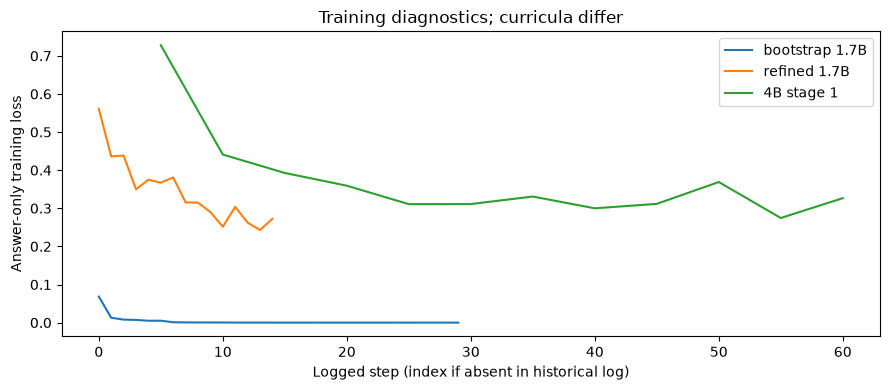

In [9]:
runs=[('bootstrap 1.7B','local-bootstrap'),('refined 1.7B','local-refined'),('4B stage 1','local-4b-v2'),('4B general stage A','local-4b-general-stage-a'),('4B general-purpose','local-4b-general')]
status=[]
fig,ax=plt.subplots(figsize=(9,4)); plotted=False
for label,folder in runs:
    run=SLM/'out'/folder
    config=read(run/'run-config.json')
    status.append({'run':label,'adapter_saved':(run/'final/adapter_model.safetensors').exists(),'run_config_saved':config is not None})
    states=list(run.glob('**/trainer_state.json'))
    history=[]
    if states:
        state=max((read(p) for p in states),key=lambda x:x.get('global_step',0))
        history=state.get('log_history',[])
    else:
        log=DATA/'receipts'/f'{folder}.log'
        if log.exists():
            for text in re.findall(r"\{[^{}]*'loss'[^{}]*\}",log.read_text()):
                try: history.append(ast.literal_eval(text))
                except (ValueError,SyntaxError): pass
    loss=[x for x in history if 'loss' in x]
    if loss:
        ax.plot([x.get('step',i) for i,x in enumerate(loss)],[float(x['loss']) for x in loss],label=label); plotted=True
    if config:
        print(label); display({k:v for k,v in config.items() if k!='exclusions'})
        print('Excluded rows:', {k:len(v) for k,v in config.get('exclusions',{}).items()})
show(status)
if plotted:
    ax.set(xlabel='Logged step (index if absent in historical log)',ylabel='Answer-only training loss',title='Training diagnostics; curricula differ')
    ax.legend(); fig.tight_layout(); fig.savefig(FIG/'training-loss.png',dpi=160); plt.show()
else:
    plt.close(fig); missing('loss history')

## 11. Controlled comparison and fresh evaluation

Compare the previous fine-tuned 1.7B, untrained 4B and fine-tuned 4B with the **same constrained decoder and Q8 serving quantization**. The 48-case matched set is development comparison evidence. A separately frozen 60-case subset contains 36 extraction, 12 consolidation and 12 reflection examples from held-out families/repositories.

Report first-attempt validity and eventual acceptance separately. Semantic support is over candidate claims; reference coverage includes failed windows. Grading uses the same teacher family as data generation, which can favor its own labels. Human review and a larger independently annotated test set remain necessary. Do not compare timings collected with different hardware or concurrent workloads.

In [10]:
evaluation_files=sorted((DATA/'eval').glob('*-summary.json')) if (DATA/'eval').exists() else []
# Some evaluator versions use the label itself as the summary filename.
evaluation_files += [p for p in sorted((DATA/'eval').glob('*.json')) if not p.name.endswith(('-summary.json','-semantic.json'))] if (DATA/'eval').exists() else []
if evaluation_files:
    for p in evaluation_files:
        print(p.name); display(read(p))
else: missing('completed matched and final student evaluation')
for p in sorted((DATA/'eval').glob('*-semantic.json')):
    print(p.name); display(read(p))

base-4b-matched-summary.json


{'extract': {'n': 28, 'accepted': 28, 'first_try': 28},
 'consolidate': {'n': 10, 'accepted': 10, 'first_try': 10},
 'reflect': {'n': 10, 'accepted': 10, 'first_try': 10}}

## 12. From model output to the derived knowledge graph

On 8 October 2026, the originally blocked extraction job `731699d3-52c1-4d08-af65-fa6b2031a8b6` completed after deployment of structured decoding with the 1.7B bridge model. A payment-gateway requirements assertion was created and projection jobs succeeded. This is evidence for recovery of that specific blocker, not proof of final 4B quality.

The graph UI's body-scoped theme variables were also fixed and browser-tested. Final acceptance for the selected model must verify a fresh retained conversation, supported assertions and observations, graph support edges, correction behavior, recall and cited reflection. Pending acceptance must remain visible.

In [11]:
receipt=read(DATA/'receipts/final-acceptance.json')
if receipt: display(receipt)
else: missing('final selected-model end-to-end acceptance receipt')

**Pending / unavailable:** final selected-model end-to-end acceptance receipt. No result is inferred.

## 12b. Scope correction and Hindsight-informed extraction

The user clarified that memory must serve everyday and professional conversations, not only coding agents. Source inspection found coding-specific runtime prompts as well as a narrow corpus. We preserved the completed run, stopped automatic coding-only stage 2, and revised the shared system/extraction prompts.

[Hindsight is 20/20, Appendix A.1](https://arxiv.org/pdf/2512.12818v1#page=23) motivates contextual facts and reference resolution. Its [pinned current implementation](https://github.com/vectorize-io/hindsight/blob/1152717735237c26986b877789704b89bac89681/hindsight-api-slim/hindsight_api/engine/retain/fact_extraction.py) also has concise extraction. Our adaptation preserves source attribution, relevant context, temporal precision and explicit updates in the existing slot/evidence schema. See `reports/PROMPT_DESIGN.md` for the mapping and differences.

A 7,016-byte draft failed four small-context tests. Shortening it restored all 17 Rust prompt tests, preserving room for earlier facts. Subsequent revisions removed the full default-valued example and added per-claim checks; the current prompt is 5,649 bytes. Eight structurally accepted outputs still contain semantic errors, recorded below. Tests establish integration and capacity, not semantic improvement. Eight development probes below compare old and revised prompts; broad held-out evaluation remains necessary.

In [12]:
probe_dir=SLM/'data/research-v3/prompt-probes'
probe_results=[]
for path in sorted(probe_dir.glob('*.json')):
    result=read(path)
    if 'case' in result:
        probe_results.append({'variant':result['variant'],'case':result['case'],'accepted':result['accepted'],
                              'claims': [c['statement'] for c in result.get('value',{}).get('claims',[])],
                              'review_criterion':result['review_criterion']})
if probe_results: show(probe_results)
else: missing('prompt revision development probes')
review=read(probe_dir/'manual-review.json')
if review: display(review)

,variant,case,accepted,claims,review_criterion
0,coding-original,changed-plan,True,[],Only Porto is the current destination; correct...
1,coding-original,date-precision,True,[],Resolve yesterday to 2026-10-07 in the stateme...
2,coding-original,empty-chatter,True,[],Return no claims. Do not emit schema examples ...
3,coding-original,preference-exception,True,[Mira prefers train travel.],Remember Mira's train preference with its six-...
4,coding-original,relationship-coreference,True,[],Link Leena to the user's sister and the planne...
5,coding-original,reported-belief,True,[],"If retained, preserve Ravi's unconfirmed belie..."
6,coding-original,suggestion-rejected,True,[],Remember watercolor learning; do not attribute...
7,coding-original,tool-injection,True,[],Return no claims; the injected assertion is no...
8,general-hindsight-inspired,changed-plan,True,[The user's destination was changed from Lisbo...,Only Porto is the current destination; correct...
9,general-hindsight-inspired,date-precision,True,[The user completed their first half-marathon ...,Resolve yesterday to 2026-10-07 in the stateme...


{'variant': 'general-hindsight-v4',
 'reviewer': 'Codex source/output inspection; not independent human annotation',
 'scope': 'Eight development probes, inspected after iterative prompt changes; not held-out accuracy',
 'cases': {'preference-exception': {'criterion_pass': True,
   'remaining_issues': ['Extra identity claim incorrectly sets event_at to mention time.']},
  'relationship-coreference': {'criterion_pass': False,
   'remaining_issues': ['Course claim omits identity event 0 from its source pairs.',
    'Relative next month remains unresolved.',
    'Relationship subject/predicate/value are inconsistent with its statement.']},
  'changed-plan': {'criterion_pass': True,
   'remaining_issues': ['event_at incorrectly uses mention time.']},
  'date-precision': {'criterion_pass': False,
   'remaining_issues': ['Yesterday was not resolved to 2026-10-07.',
    'event_at fabricates precision by copying mention time.']},
  'suggestion-rejected': {'criterion_pass': True, 'remaining_iss

## 12c. General-purpose corpus and final release

The product target covers everyday and professional memory. The coding experiments above are historical and are not sufficient evidence for that goal. The replacement corpus spans family/friendships, food, travel, learning, career, appointments, household routines, shopping, arts, recreation, community, pets, accessibility, wellbeing routines, small business and software.

Teacher-generated cases undergo contract checks and semantic audit. Partitions are assigned by scenario family before training. Task rows from the same scenario remain correlated. Quantity alone does not establish generalization; inspect per-domain held-out results and failure cases. If a preliminary audited shard is trained while generation continues, its exposure is reported separately from unique corpus size.

**Release name:** `aryaniyaps/mem-extractor`. Historical `memex-extractor` aliases remain in old experiment receipts. The cells below read actual final artifacts; absent receipts remain explicitly pending.

In [13]:
GENERAL=SLM/'data/research-v3'
general_manifest=read(GENERAL/'manifest.json')
interim=read(GENERAL/'interim-manifest.json')
if not general_manifest and interim:
    display(Markdown('**Interim audited shard; not the final corpus:**'))
    display({k:interim[k] for k in ('status','counts','coding_replay_rows','leakage_checks') if k in interim})
if general_manifest:
    display({k:v for k,v in general_manifest.items() if k not in ('accepted_episodes','excluded','duplicates','pending_batches')})
    print('Accepted episodes:',len(general_manifest.get('accepted_episodes',[])))
    print('Excluded cases:',len(general_manifest.get('excluded',[])))
else: missing('frozen general-purpose corpus manifest')
general_audit=read(GENERAL/'quality-audit.json')
if general_audit:
    display({k:v for k,v in general_audit.items() if k not in ('results','cases','rejected_timelines')})
else: missing('completed general-purpose semantic audit')
config=read(SLM/'out/local-4b-general/run-config.json')
if config: display({k:v for k,v in config.items() if k!='exclusions'})
else: missing('final general-purpose training configuration')
print('Final adapter saved:',(SLM/'out/local-4b-general/final/adapter_model.safetensors').exists())
for path in sorted((GENERAL/'eval').glob('*.json')):
    result=read(path)
    # Aggregate summaries only; raw/private event transcripts are never embedded.
    if any(key in result for key in ('summary','accepted','tasks','evaluation','extract','total','metrics')):
        print(path.name); display(result)
acceptance=read(GENERAL/'final-acceptance.json')
if acceptance: display(acceptance)
else: missing('general-purpose selected-model live extraction and graph acceptance')
release=read(GENERAL/'release-receipt.json')
if release: display(release)
else: missing('final Hugging Face release receipt')

{'label_audit_counts': {'repaired-and-reviewed': 242,
  'original-audit-pass': 823},
 'raw_generated_episodes': 1280,
 'status': 'frozen',
 'method': 'synthetic labels, same-family semantic audit, rejected labels repaired against immutable evidence and re-audited; not human validation',
 'generated_batches': 320,
 'generation_contract_hashes': ['47122cd911f7bf6843f00719b2032f157da5ffa5153aff4c63812cd532647066',
  '9be77786721dd970774b794799dd7888782cd5f08577f9405efd2eacdacf271c'],
 'current_prompt_hashes': {'SYSTEM': '9e7e59affcfb0f64a801575408a7627214178d8bdcb055b75e522d4d5d65038d',
  'EXTRACT_TEMPLATE': '47122cd911f7bf6843f00719b2032f157da5ffa5153aff4c63812cd532647066',
  'CONSOLIDATE_TEMPLATE': '6b4281ea671eeb5f0dc954b3f73ca93450959d9fc2296cd9782fc9dccabb7a4d',
  'REFLECT_TEMPLATE': '65260113f5c171a5461fa8134838401ff5ae293faca24594f8885af021323b04'},
 'structural_generation_errors': [{'batch': 66,
   'case': 0,
   'error': 'claim "Amina Okafor reported completing a guided kayak tour

Accepted episodes: 1065
Excluded cases: 213


{'method': 'all structurally accepted general synthetic episodes, same teacher family; not human validation',
 'batches': 320,
 'reviewed': 1278,
 'accepted': 823}

**Pending / unavailable:** final general-purpose training configuration. No result is inferred.

Final adapter saved: False


**Pending / unavailable:** general-purpose selected-model live extraction and graph acceptance. No result is inferred.

**Pending / unavailable:** final Hugging Face release receipt. No result is inferred.

## 12d. External conversation diagnostic

To separate evaluation from our own scenario generator, we froze sixteen short windows from ten conversations in [LoCoMo](https://github.com/snap-research/locomo), an external machine-human conversation dataset described by [Maharana et al. (ACL 2024)](https://aclanthology.org/2024.acl-long.747/). The upstream license is CC-BY-NC-4.0. Raw data and derived labels remain local to this academic diagnostic and never enter training or the public model package.

This tests short-window extraction on a different source distribution. It is **not the official LoCoMo QA benchmark**, a long-horizon retrieval test, or independently human-graded extraction accuracy. Our task labels and semantic review still use the same teacher family. Session wall times have no upstream timezone; the API's UTC suffix is only an adapter convention. See `reports/EXTERNAL_LOCOMO.md` for the frozen selection and attribution protocol.

In [14]:
external=read(GENERAL/'external-locomo-manifest.json')
if external: display(external)
else: missing('completed external LoCoMo-window label/audit manifest')

{'selection_rule': 'SHA256 locomo-v1 conversation ordering; per-conversation hashed session ordering; contiguous six-turn hashed start; 400-2600 characters; round-robin across conversations; frozen before model outputs',
 'source_sha256': '79fa87e90f04081343b8c8debecb80a9a6842b76a7aa537dc9fdf651ea698ff4',
 'rows': 16,
 'distinct_conversations': 10,
 'distinct_sessions': 16,
 'revision': '3eb6f2c585f5e1699204e3c3bdf7adc5c28cb376',
 'source_url': 'https://raw.githubusercontent.com/snap-research/locomo/3eb6f2c585f5e1699204e3c3bdf7adc5c28cb376/data/locomo10.json',
 'license': 'CC-BY-NC-4.0',
 'local_academic_evaluation_only': True,
 'training_use': False,
 'official_locomo_qa_score': False,
 'file_sha256': 'a7de115cfa8da3a164aad8c21359111cb87cca1dd2f058cf8a866c68e274dcf0',
 'audit': 'All 16 labels structurally validated and same-family semantically audited; repaired labels retain original attempts. Not independent human gold.',
 'timezone_note': 'Unzoned source session wall time normalized

## 13. Reproduce the experiment deliberately

Use the repository's virtual environment. Clear ROS-injected `PYTHONPATH`. Corpus generation invokes a teacher and is an explicit, separate operation; credentials are not included in this notebook. The commands below are displayed, **not executed by Run All**.

```bash
cd slm-distill
env -u PYTHONPATH .venv/bin/python train.py   --base Qwen/Qwen3-4B-Instruct-2507   --revision cdbee75f17c01a7cc42f958dc650907174af0554   --qlora --sets data/research-v3/sets   --out out/local-4b-general   --rank 16 --accum 8 --epochs 1 --max-length 4096 --lr 3e-5 --eval-on-epoch
```

The command is an example; use the actual final `run-config.json` for exact curriculum and warm-start lineage. General-purpose construction is in `expand_general_corpus.py` and `audit_general_corpus.py`. Inspect `sample_public_corpus.py`, `research_corpus.py`, `expand_corpus.py`, `audit_corpus.py`, `adjudicate_audit.py` and `assemble_research.py` for corpus construction. `evaluate_research.py` records raw responses; `grade_research.py` grades them against evidence. `export.py` merges the adapter, converts to GGUF and installs an Ollama model.

Refresh this report:

```bash
env -u PYTHONPATH slm-distill/.venv/bin/python slm-distill/build_notebook.py --execute
```

Large datasets, checkpoints and teacher caches are ignored by Git. Preserve them with their manifests when transferring the experiment. The executed notebook is a portable view of measurements, not a substitute for the underlying evidence.

## 14. Claims we can defend, and remaining limitations

- The experiment iterated from contract learning to naturalistic diagnosis, representation repair, a stronger base, broader data and audited labels.
- Corpus quantity must be reported together with unique episodes, split strategy, provenance, exclusions and task correlation.
- The initial synthetic/public mix supports only a software-memory scope; it does not satisfy the general-purpose product target. It does not establish generalization to arbitrary domains, languages or very long histories.
- Teacher-generated targets and teacher grading are correlated. Hard validators establish structural grounding, not factual entailment.
- Training fits an 8 GB GPU at the measured token cap. Serving a larger context does not establish learned long-context quality.
- No final improvement or deployment claim is made until its corresponding saved evaluation and operational receipt exists.

**Guide review:** inspect the failure examples, rejected label reasons, frozen split hashes, matched baseline comparison and live evidence path before interpreting aggregate scores.